# Proyek Analisis Data: Bike Sharing
- **Nama:** Suyeni Meisyalena
- **Email:** meisyalena12@gmail.com
- **ID Dicoding:** CDCC277D6X0986

### **Latar Belakang**
Sistem penyewaan sepeda merupakan generasi baru dari rental sepeda yang dimana mencakup keanggotaan, peminjaman, hingga pengembalian secara otomatis. Sistem ini mudah ditemukan di lokasi tertentu dan dapat mengembalikannya di lokasi berbeda. Tentu hal ini sangat memudahkan para pekerja yang menggunakan kendaraan umum.

### **Data Set**
Sistem penyewaan sepeda ini sangat berkaitan dengan faktor lingkungan dan perubahan musim. Data ini mencakup kondisi cuaca,jumlah hari dalam seminggu, 4 musim, jumlah jam dalam sehari, dan lain-lain yang bisa berdampak kepada perilaku penyewa sepeda. Data ini memuat tahun 2011 dan 2012 yang bisa diakses secara publik pada website http://capitalbikeshare.com/system-data.

### **Files**
	- Readme.txt
	- hour.csv : jumlah data penyewa sepeda di setiap jamnya. Baris: 17379 hours
	- day.csv : jumlah data penyewa sepeda di setiap harinya. Baris: 731 days

### **Dataset characteristics**
Kedua data hour.csv dan day.csv memiliki kolom-kolom berikut, kecuali hr tidak tersedia pada data day.csv

	- instant: indeks
	- dteday : tanggal
	- season : musim (1:springer [musim semi], 2:summer[musim panas], 3:fall [musim gugur], 4:winter[musim dingin])
	- yr : tahun (0: 2011, 1:2012)
	- mnth : bulan ( 1 to 12)
	- hr : jam (0 to 23)
	- holiday : apakah hari tersebut hari libur atau bukan
	- weekday : jumlah hari dalam seminggu
	- workingday : jika bukan hari libur nasional atau weekend (sabtu/minggu) maka nilainya 1, yang lainnya 0
	+ weathersit :
		- 1: Cerah/Cerah Berawan
		- 2: Berkabut/Mendung
		- 3: Cuaca Buruk Ringan
		- 4: Cuaca Ekstrim
	- temp : suhu dalam Celcius yang sudah dinormalisasikan (nilai dibagi dengan 41)
	- atemp: suhu yang dirasakan dalam Celcius yang sudah dinormalisasikan (nilai dibagi dengan 50)
	- hum: kelembapan yang sudah dinormalisasikan (nilai dibagi dengan 100)
	- windspeed: kecepatan angin yang sudah dinormalisasikan (nilai dibagi dengan 67)
	- casual: jumlah pengguna kasual (misal, untuk rekreasi)
	- registered: jumlah pengguna terdaftar atau jadi anggota (misal, untuk transportasi menuju kantor)
	- cnt: total keseluruhan dari pengguna kasual dan pengguna terdaftar


## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Faktor apa yang paling berpengaruh dalam memprediksi lonjakan permintaan penyewaan sepeda?

- **Pertanyaan 2:** Berapa persen peningkatan penyewaan sepeda pada pada jam sibuk (07:00-09:00 dan 17:00-19:00) di hari kerja?

- **Pertanyaan 3:** Apakah hari libur memengaruhi penyewaan sepeda pada tahun 2012?


## Import Semua Packages/Library yang Digunakan

In [280]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [281]:
!unzip -o Bike-sharing-dataset.zip

Archive:  Bike-sharing-dataset.zip
  inflating: Readme.txt              
  inflating: day.csv                 
  inflating: hour.csv                


In [282]:
df_day = pd.read_csv('/content/day.csv')
df_day

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


**Ringkasan Struktur Data**
* Dataset terdiri dari **731 entri** dan **16 kolom**.

In [283]:
df_hour = pd.read_csv('/content/hour.csv')
df_hour

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Ringkasan Struktur Data**
* Dataset terdiri dari **17379 entri** dan **17 kolom**.

### Assessing Data

#### Identifying ... problem

**Steps to Take:**
Setelah berhasil mengumpulkan data, langkah selanjutnya yaitu melakukan penilaian (assessing) untuk mengidentifikasi masalah kualitas dalam dataset.

1. **Memeriksa Tipe Data**.
Menggunakan `df_day.info()` dan `df_hour.info()`untuk memastikan kolom `dteday`sudah bertipe `datetime`, bukan `object`

2. **Memeriksa Missing Values**.
Menggunakan `df_day.isna().sum()` dan `df_hour.isna().sum()`untuk menghitung jumlah data yang hilang (*null/NaN*) di setiap kolom.

3. **Memeriksa Data Duplikat**.
Menggunakan `df_day.duplicated().sum()` dan `df_hour.duplicated().sum()`untuk memastikan tidak ada data berulang.

4. **Ringkasan Parameter Statistik:**.
Menggunakan `df_day.describe()` dan `df_hour.describe()`untuk mendapatkan nilai mean, median, min, max, dan kuartil.

5. **Mendeteksi Outliers**.
Meninjau nilai minimum dan maksimum pada kolom `hum`, `temp`, `atemp`, dan `windspeed` untuk mendeteksi adanya data error (seperti nilai 0 pada kelembapan)

## df_day

In [284]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [285]:
df_day.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [286]:
df_day.duplicated().sum()

np.int64(0)

In [287]:
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Terdapat data anomali yang memiliki nilai kelembapan 0.

In [288]:
print("Cek Missing Values:\n", df_day.isna().sum())
print("\nCek Duplikat:", df_day.duplicated().sum())

Cek Missing Values:
 instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Cek Duplikat: 0


**Inkonsistensi Tipe Data**.
* **`dteday`**: Kolom ini memiliki tipe data `object` (string). Seharusnya kolom ini bertipe numerik (`float` atau `int`) agar bisa digunakan dalam perhitungan statistik.

**Tidak Ada Masalah Kualitas Data (Missing Values) dan Duplikat**

Tidak ditemukan adanya nilai yang hilang dan duplicate pada semua kolom tersebut.

**Ringkasan Struktur Data**
* Komposisi tipe data terdiri dari: `float64` (4 kolom), `int64` (11 kolom), dan `object` (1 kolom).

## df_hour

In [289]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [290]:
df_hour.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [291]:
df_hour.duplicated().sum()

np.int64(0)

In [292]:
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


Terdapat data anomali yang memiliki nilai kelembapan 0.

In [293]:
print("Cek Missing Values: \n", df_hour.isna().sum())
print("\nCek Duplikat:", df_hour.duplicated().sum())

Cek Missing Values: 
 instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Cek Duplikat: 0


**Inkonsistensi Tipe Data**.
* **`dteday`**: Kolom ini memiliki tipe data `object` (string). Seharusnya kolom ini bertipe numerik (`float` atau `int`) agar bisa digunakan dalam perhitungan statistik.

**Tidak Ada Masalah Kualitas Data (Missing Values)**

Tidak ditemukan adanya nilai yang hilang pada semua kolom tersebut.

**Ringkasan Struktur Data**
* Komposisi tipe data terdiri dari: `float64` (4 kolom), `int64` (12 kolom), dan `object` (1 kolom).
* Dataset `df_hour` tidak ada nilai yang kosong dan duplikat.

### Cleaning Data

Setelah mengidentifikasi berbagai masalah pada tahap *Assessing Data*, saatnya melakukan *Cleaning Data* untuk memastikan data sudah bersih dan siap melakukan analisis. Proses ini mencakup perbaikan tipe data dan eliminasi anomali (*outliers*).

**Memperbaiki Tipe Data**
* Masalah yang ditemukan pada kolom C terbaca sebagai `object`. Oleh karena itu, perlu mengubahnya menjadi (`float` atau `int`)

**Menangani Outliers (Anomali)**

* **`hum`**: Menghapus data yang memiliki nilai kelembapan 0.

In [294]:
datetime_colums = ['dteday']
for column in datetime_colums:
    df_day[column] = pd.to_datetime(df_day[column])
    df_hour[column] = pd.to_datetime(df_hour[column])

In [295]:
df_day.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

In [296]:
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

In [297]:
# Menangani Outliers
data_nol_day = (df_day['hum'] == 0).sum()
data_nol_hour = (df_hour['hum'] == 0).sum()

In [298]:
df_day = df_day[df_day['hum'] != 0].reset_index(drop=True)
df_hour = df_hour[df_hour['hum'] != 0].reset_index(drop=True)
print(f"Jumlah data hum = 0 pada df_day: {data_nol_day}")
print(f"Jumlah data hum = 0 pada df_hour: {data_nol_hour}")

Jumlah data hum = 0 pada df_day: 1
Jumlah data hum = 0 pada df_hour: 22


In [299]:
# Mengembalikan data ke nilai semula
df_day['temp'] = df_day['temp'] * 41
df_day['atemp'] = df_day['atemp'] * 50
df_day['hum'] = df_day['hum'] * 100
df_day['windspeed'] = df_day['windspeed'] * 67

df_hour['temp'] = df_hour['temp'] * 41
df_hour['atemp'] = df_hour['atemp'] * 50
df_hour['hum'] = df_hour['hum'] * 100
df_hour['windspeed'] = df_hour['windspeed'] * 67

In [300]:
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [301]:
df_hour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,9.84,14.395,81.0,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,9.02,13.635,80.0,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,9.02,13.635,80.0,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,9.84,14.395,75.0,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,9.84,14.395,75.0,0.0,0,1,1


In [302]:
df_day.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,366.406849,2012-01-01 09:45:51.780822016,2.498630,0.501370,6.524658,0.028767,2.995890,0.683562,1.393151,20.316746,23.723774,62.875419,12.756024,849.275342,3660.390411,4509.665753
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,18.791700,1.500244,2.000000,20.000000,22.000000
25%,184.250000,2011-07-03 06:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.052075,9.041650,316.250000,2502.250000,3169.750000
50%,366.500000,2012-01-01 12:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.708350,12.125057,717.000000,3664.500000,4548.500000
75%,548.750000,2012-07-01 18:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,73.031275,15.624869,1096.500000,4783.250000,5966.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000
std,211.023699,NaN,1.110184,0.500341,3.451815,0.167266,2.005817,0.465405,0.542015,7.508500,8.151989,14.061409,5.192892,686.449738,1557.149836,1933.194931


In [303]:
df_hour.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357.000000,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,8699.034107,2012-01-02 13:12:48.035950848,2.503543,0.503198,6.542260,11.545889,0.028807,3.002420,0.682318,1.423403,20.382081,23.794466,62.802385,12.730444,35.718788,153.948551,189.667339
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.820000,0.000000,8.000000,0.000000,0.000000,0.000000,1.000000
25%,4362.000000,2011-07-05 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,13.940000,16.665000,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8701.000000,2012-01-03 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,20.500000,24.240000,63.000000,12.998000,17.000000,116.000000,142.000000
75%,13040.000000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,27.060000,31.060000,78.000000,16.997900,48.000000,220.000000,281.000000
max,17379.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000
std,5013.782462,NaN,1.106327,0.500004,3.438645,6.914537,0.167268,2.006728,0.465588,0.637492,7.898036,8.596065,19.175450,8.196926,49.321693,151.382189,181.409297


Data `df_day` dan `df_hour`dikembalikan sesuai nilai sebenarnya untuk memudahkan dalam membaca hasil insight yang dihasilkan.



In [304]:
# Cek Kembali Outliers
data_nol_day = (df_day['hum'] == 0).sum()
data_nol_hour = (df_hour['hum'] == 0).sum()
df_day = df_day[df_day['hum'] != 0].reset_index(drop=True)
df_hour = df_hour[df_hour['hum'] != 0].reset_index(drop=True)
print(f"Jumlah data hum = 0 pada df_day: {data_nol_day}")
print(f"Jumlah data hum = 0 pada df_hour: {data_nol_hour}")

Jumlah data hum = 0 pada df_day: 0
Jumlah data hum = 0 pada df_hour: 0


## Exploratory Data Analysis (EDA)

### Explore ...

In [305]:
df_hour.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357.000000,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,8699.034107,2012-01-02 13:12:48.035950848,2.503543,0.503198,6.542260,11.545889,0.028807,3.002420,0.682318,1.423403,20.382081,23.794466,62.802385,12.730444,35.718788,153.948551,189.667339
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.820000,0.000000,8.000000,0.000000,0.000000,0.000000,1.000000
25%,4362.000000,2011-07-05 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,13.940000,16.665000,48.000000,7.001500,4.000000,34.000000,40.000000
50%,8701.000000,2012-01-03 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,20.500000,24.240000,63.000000,12.998000,17.000000,116.000000,142.000000
75%,13040.000000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,27.060000,31.060000,78.000000,16.997900,48.000000,220.000000,281.000000
max,17379.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,41.000000,50.000000,100.000000,56.996900,367.000000,886.000000,977.000000
std,5013.782462,NaN,1.106327,0.500004,3.438645,6.914537,0.167268,2.006728,0.465588,0.637492,7.898036,8.596065,19.175450,8.196926,49.321693,151.382189,181.409297


In [306]:
# Menghitung korelasi kolom numerik terhadap kolom total pengguna casual dan terdaftar (cnt)
df_day[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()['cnt']

,cnt
temp,0.627774
atemp,0.631439
hum,-0.114625
windspeed,-0.232790
cnt,1.000000


Jadi, temp dan atemp berpengaruh terhadap jumlah penyewaan sepeda.

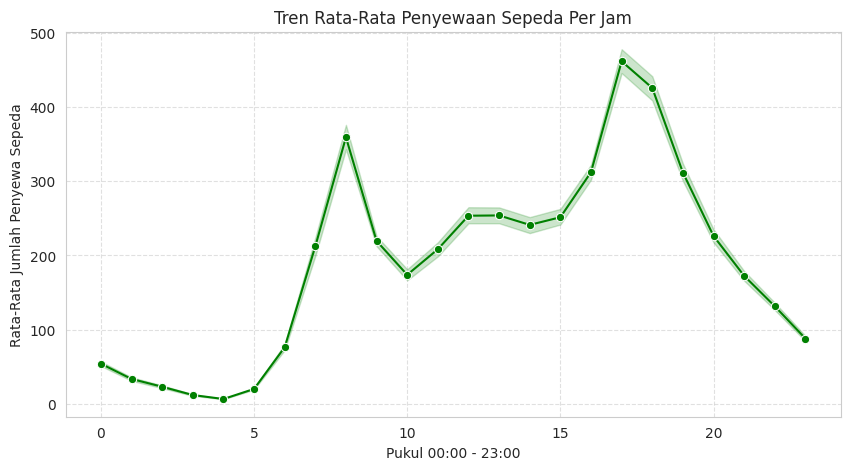

In [307]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_hour, x='hr', y='cnt', color='green', marker='o')

plt.title('Tren Rata-Rata Penyewaan Sepeda Per Jam', fontsize=12)
plt.xlabel('Pukul 00:00 - 23:00', fontsize=10)
plt.ylabel('Rata-Rata Jumlah Penyewa Sepeda', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Berdasarkan grafik tersebut diperoleh peningkatan penyewa sepeda mulai dari pukul 05.00 - 08.00 dan mulai melonjak kembali pada pukul 16.00 - 17.00 pada jam kerja.

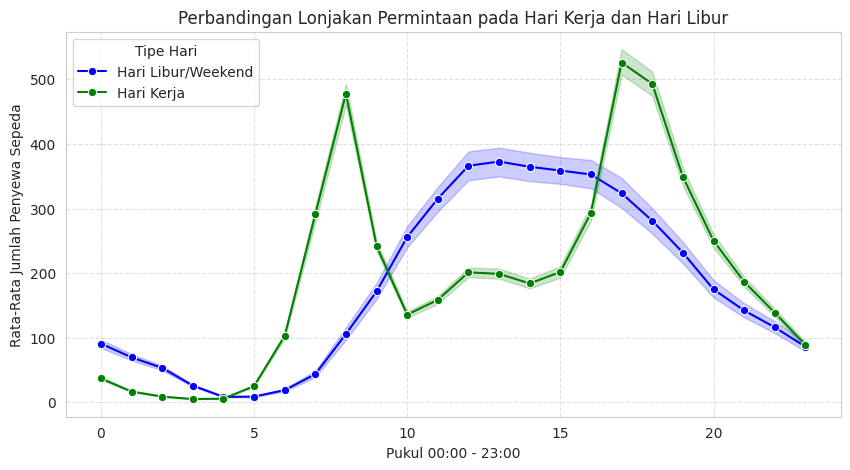

In [308]:
df_plot = df_hour.copy()
df_plot['workingday'] = df_plot['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_plot, x='hr', y='cnt', hue='workingday', marker='o', palette=['blue', 'green'])

plt.title('Perbandingan Lonjakan Permintaan pada Hari Kerja dan Hari Libur', fontsize=12)
plt.xlabel('Pukul 00:00 - 23:00', fontsize=10)
plt.ylabel('Rata-Rata Jumlah Penyewa Sepeda', fontsize=10)
plt.legend(title='Tipe Hari')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Pada hari libur/weekend, penyewa sepeda lebih banyak pada saat jam orang bekerja, pukul 08.00 - 15.00.

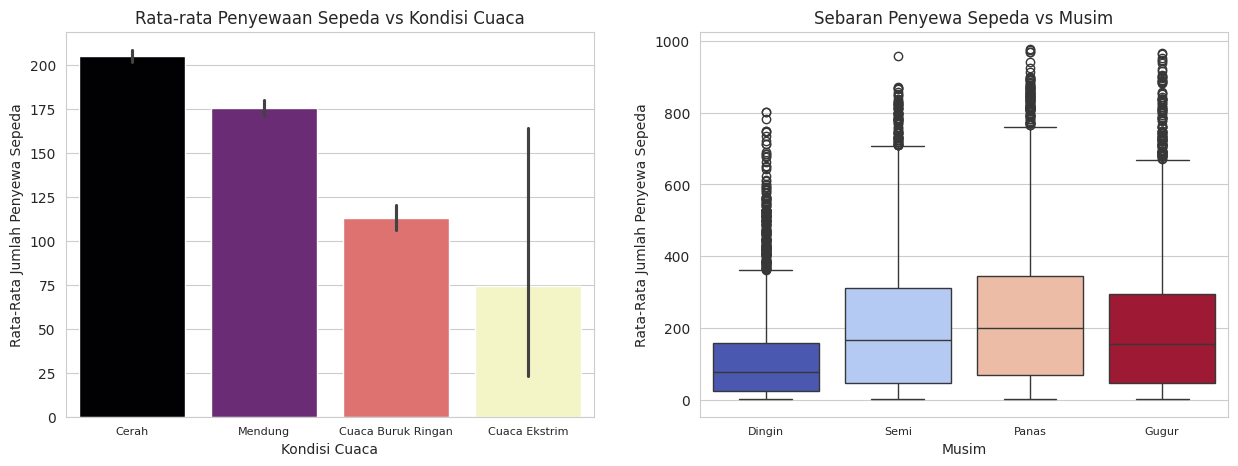

In [309]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Grafik Cuaca
sns.barplot(data=df_hour, x='weathersit', y='cnt', hue='weathersit', ax=axes[0], palette='magma', legend=False)
axes[0].set_title('Rata-rata Penyewaan Sepeda vs Kondisi Cuaca')
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(['Cerah', 'Mendung', 'Cuaca Buruk Ringan', 'Cuaca Ekstrim'], fontsize=8)
axes[0].set_xlabel('Kondisi Cuaca', fontsize=10)
axes[0].set_ylabel('Rata-Rata Jumlah Penyewa Sepeda', fontsize=10)

# Grafik Musim
sns.boxplot(data=df_hour, x='season', y='cnt', hue='season', ax=axes[1], palette='coolwarm', legend=False)
axes[1].set_title('Sebaran Penyewa Sepeda vs Musim')
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['Dingin', 'Semi', 'Panas', 'Gugur'], fontsize=8)
axes[1].set_xlabel('Musim', fontsize=10)
axes[1].set_ylabel('Rata-Rata Jumlah Penyewa Sepeda', fontsize=10)

plt.show()

Berdasarkan grafik tersebut menunjukkan bahwa lebih banyak penyewa sepeda pada saat cuaca cerah dibandingkan cuaca ekstrim. Sehingga dapat disimpulkan bahwa cuaca juga memengaruhi penyewaan sepeda.

In [310]:
df_hari_kerja = df_hour[df_hour['workingday'] == 1]
jam_sibuk = [7, 8, 9, 17, 18, 19]

df_sibuk = df_hari_kerja[df_hari_kerja['hr'].isin(jam_sibuk)]
df_normal = df_hari_kerja[~df_hari_kerja['hr'].isin(jam_sibuk)]

avarage_sibuk = df_sibuk['cnt'].mean()
avarage_normal = df_normal['cnt'].mean()

increase_percent = ((avarage_sibuk - avarage_normal) / avarage_normal) * 100

print(f"Rata-rata penyewaan jam sibuk: {avarage_sibuk:.2f}")
print(f"Rata-rata penyewaan jam biasa: {avarage_normal:.2f}")
print(f"Persentase Peningkatan Penyewaan Sepeda: {increase_percent:.2f}%")

Rata-rata penyewaan jam sibuk: 396.68
Rata-rata penyewaan jam biasa: 125.29
Persentase Peningkatan Penyewaan Sepeda: 216.60%


In [311]:
df_2012 = df_day[df_day['yr'] == 1]

holiday_impact = df_2012.groupby('holiday')['cnt'].mean()

avarage_holiday = holiday_impact[1]
avarage_non_holiday = holiday_impact[0]
diff_percent = ((avarage_holiday - avarage_non_holiday) / avarage_non_holiday) * 100

print(f"Rata-rata penyewa sepeda di Hari Kerja (2012): {avarage_non_holiday:.2f}")
print(f"Rata-rata penyewa sepeda di Hari Libur (2012): {avarage_holiday:.2f}")
print(f"Persentase Perbedaan: {diff_percent:.2f}%")

Rata-rata penyewa sepeda di Hari Kerja (2012): 5637.08
Rata-rata penyewa sepeda di Hari Libur (2012): 4401.18
Persentase Perbedaan: -21.92%


## Visualization & Explanatory Analysis

### **Pertanyaan 1:** Faktor apa yang paling signifikan dalam memprediksi lonjakan permintaan penyewaan sepeda?

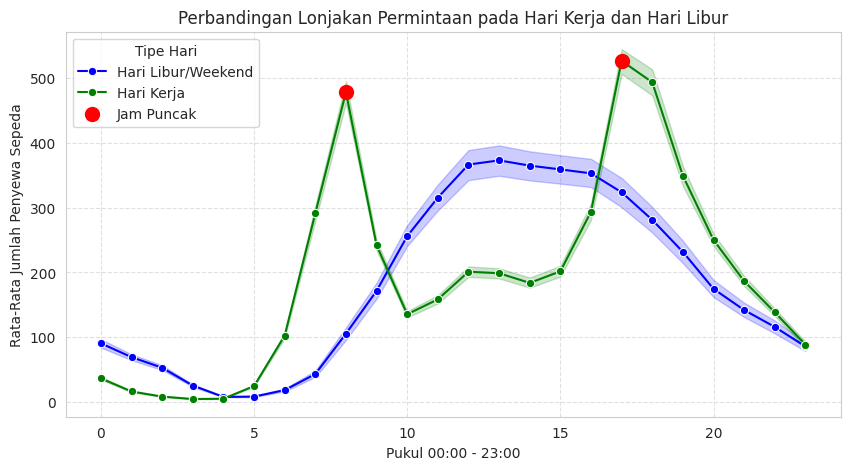

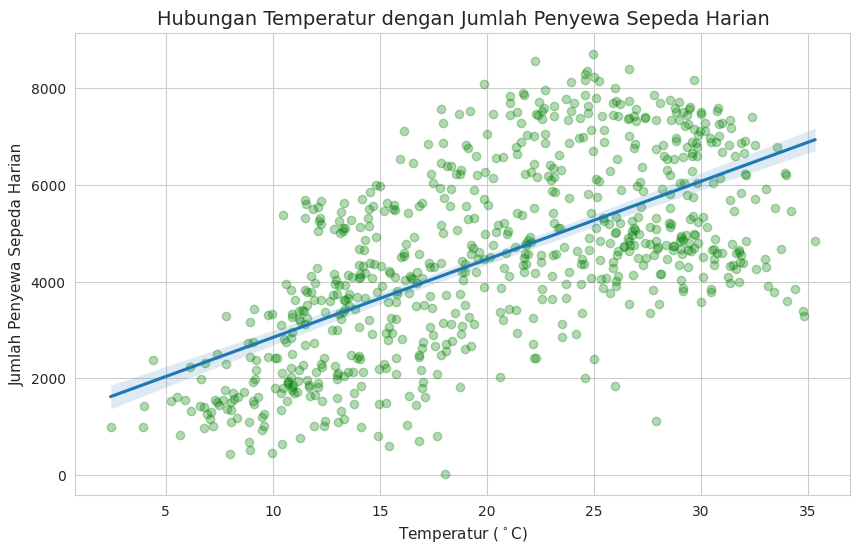

In [312]:
# Grafik Perbandingan Lonjakan Permintaan pada Hari Kerja dan Hari Libur
df_plot = df_hour.copy()
df_plot['workingday'] = df_plot['workingday'].map({0: 'Hari Libur/Weekend', 1: 'Hari Kerja'})

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_plot, x='hr', y='cnt', hue='workingday', marker='o', palette=['blue', 'green'])

df_avg = df_plot.groupby(['hr', 'workingday'])['cnt'].mean().reset_index()

puncak_pagi = df_avg[(df_avg['hr'] == 8) & (df_avg['workingday'] == 'Hari Kerja')]
puncak_sore = df_avg[(df_avg['hr'] == 17) & (df_avg['workingday'] == 'Hari Kerja')]

# Titik Jam 8
plt.scatter(puncak_pagi['hr'], puncak_pagi['cnt'], color='red', s=100, zorder=5, label='Jam Puncak')
# Titik Jam 17
plt.scatter(puncak_sore['hr'], puncak_sore['cnt'], color='red', s=100, zorder=5)

plt.title('Perbandingan Lonjakan Permintaan pada Hari Kerja dan Hari Libur', fontsize=12)
plt.xlabel('Pukul 00:00 - 23:00', fontsize=10)
plt.ylabel('Rata-Rata Jumlah Penyewa Sepeda', fontsize=10)
plt.legend(title='Tipe Hari')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()
print()

# Grafik Hubungan Temperatur dengan Jumlah Penyewa Sepeda Harian
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df_day,
    x='temp',
    y='cnt',
    scatter_kws={'alpha': 0.3, 'color': 'green'}
)

plt.title('Hubungan Temperatur dengan Jumlah Penyewa Sepeda Harian', fontsize=14)
plt.xlabel(r'Temperatur ($^\circ$C)', fontsize=11)
plt.ylabel('Jumlah Penyewa Sepeda Harian', fontsize=11)

plt.show()

Berdasarkan grafik pertama, dapat kita lihat bahwa terdapat lonjakan permintaan yang cukup signifikan pada pukul 08.00 dan 17.00 pada hari kerja. Jam tersebut merupakan jam awal dan jam keluar sebagian orang bekerja. Hal tersebut menunjukkan bahwa mayoritas penyewa sepeda pada jam tersebut merupakan pekerja.

Melihat grafik kedua, temperatur juga memengaruhi seseorang untuk menyewa sepeda. Semakin hangat suhunya, semakin banyak orang yang menyewa sepeda. Namun, sebaliknya jika suhu semakin dingin maka peminat penyewa sepeda pun ikut menurun.

Jadi, faktor yang memengaruhi penyewaan sepeda yaitu waktu dan temperatur.

### **Pertanyaan 2:** Berapa persen peningkatan penyewaan sepeda pada pada jam sibuk (07:00-09:00 dan 17:00-19:00) di hari kerja?


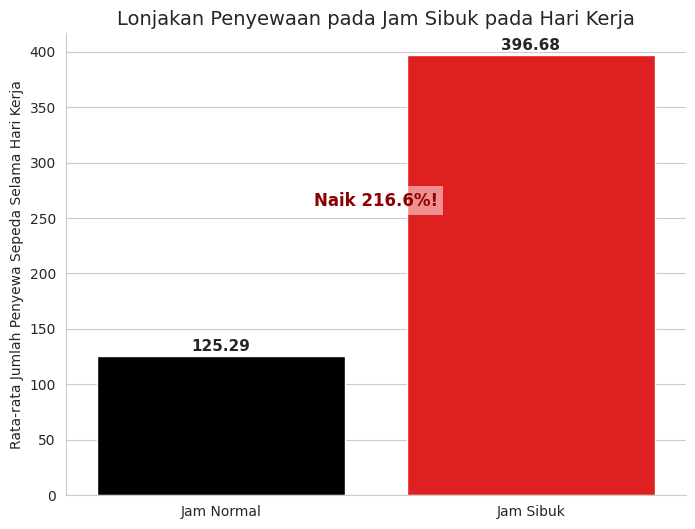

In [313]:
plt.figure(figsize=(8, 6))
kategori = ['Jam Normal', 'Jam Sibuk']
values = [avarage_normal, avarage_sibuk]

sns.barplot(x=kategori, y=values, hue=kategori, palette=['black', 'red'], legend=False)

plt.title('Lonjakan Penyewaan pada Jam Sibuk pada Hari Kerja', fontsize=14)
plt.ylabel('Rata-rata Jumlah Penyewa Sepeda Selama Hari Kerja')

for i, v in enumerate(values):
    plt.text(i, v + 5, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# Menambahkan keterangan persentase di tengah
plt.text(0.5, (avarage_sibuk + avarage_normal)/2, f'Naik {increase_percent:.1f}%!',
         color='darkred', fontweight='bold', fontsize=12, ha='center',
         bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

sns.despine()
plt.show()

Berdasarkan grafik di atas, terlihat bahwa pada jam sibuk terdapat lonjakan permintaan yang signifikan yakni 216,6% dibandingkan dengan jam normal. Dari hal tersebut, dapat kita simpulkan bahwa jumlah sepeda harus diprioritaskan saat jam sibuk untuk menghindari potensi kehilangan pendapatan.

### **Pertanyaan 3:** Apakah hari libur memengaruhi penyewaan sepeda pada tahun 2012?


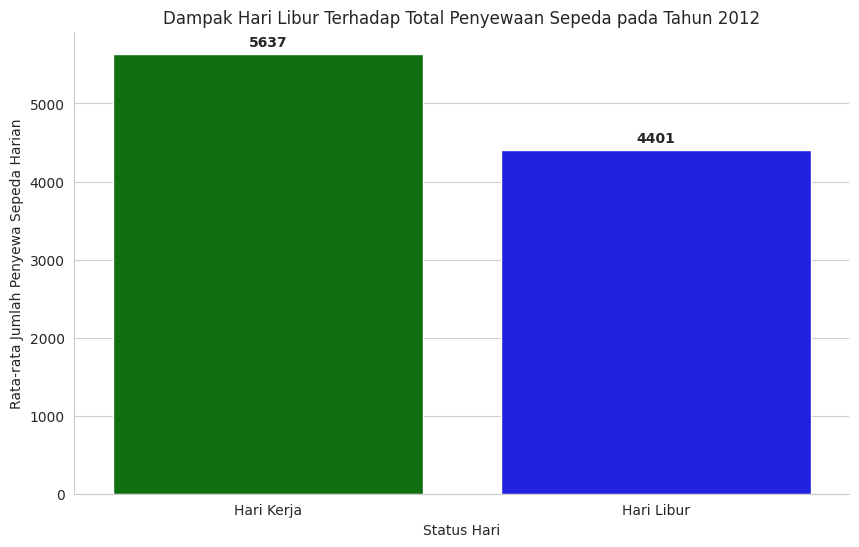

In [314]:
plt.figure(figsize=(10, 6))
labels = ['Hari Kerja', 'Hari Libur']
values = [avarage_non_holiday, avarage_holiday]

sns.barplot(x=labels, y=values, hue=labels, palette=['green','blue'], legend=False)

plt.title('Dampak Hari Libur Terhadap Total Penyewaan Sepeda pada Tahun 2012', fontsize=12)
plt.ylabel('Rata-rata Jumlah Penyewa Sepeda Harian')
plt.xlabel('Status Hari')

# Tambahkan label angka di atas batang
for i, v in enumerate(values):
    plt.text(i, v + 100, f'{int(v)}', ha='center', fontweight='bold')

sns.despine()
plt.show()

Berdasarkan grafik di atas, dapat kita lihat bahwa penyewa sepeda lebih banyak saat hari kerja dibandingkan hari libur. Hal ini terjadi pada tahun 2012. Pada hari kerja terdapat 5637 penyewa, sedangkan saat hari libur hanya menyentuh angka 4401 penyewa. Ini mengartikan bahwa sebagian besar penyewa sepeda merupakan pekerja karena pada saat libur nasional, banyak perkantoran yang tidak beroperasional.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Jadi, faktor yang paling signifikan dalam memprediksi lonjakan permintaan penyewaan sepeda adalah waktu dan temperatur.

- **Conclusion pertanyaan 2:** Jadi persentase peningkatan penyewaan sepeda pada pada jam sibuk (07:00-09:00 dan 17:00-19:00) di hari kerja adalah 216,6%. Ini mengartikan banyak sekali pekerja yang menggunakan sepeda untuk pergi dan pulang bekerja.

- **Conclusion pertanyaan 3:** Jadi, hari libur memengaruhi penyewaan sepeda pada tahun 2012 karena terdapat penurunan lebih dari 1000 penyewa sepeda.

**Rekomendasi Action Item:**

Berdasarkan analisis data tersebut, maka sepeda perlu disiapkan lebih banyak saat jam sibuk hari kerja untuk mencegah potensi kehilangan pendapatan yang cukup signifikan karena saat jam tersebut terdapat kenaikan hingga 216,6% dibandingkan jam normal. Oleh sebab itu, perlu dimaksimalkan pada hari kerja karena kita melihat data tahun 2012, saat hari libur penyewa sepeda lebih sedikit dibandingkan saat hari kerja.

In [317]:
df_day.to_csv("df_day.csv", index=False)
df_hour.to_csv("df_hour.csv", index=False)